# Nieuwe methode proberen

Do your imports

## TACKLE TO DO's!!

In [1]:
# === Standard Library ===
from pathlib import Path
import pickle

# === Scientific & Data Libraries ===
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm


# === Geospatial Libraries ===
import geopandas as gpd
import rasterio
import folium
from shapely.geometry import box, Point, LineString, Polygon, shape
from pyproj import Transformer
import networkx as nx
import geohexgrid as ghg
from shapely.ops import transform


# === RA2CE Project Imports ===
from ra2ce.network.network_config_data.enums.aggregate_wl_enum import AggregateWlEnum
from ra2ce.network.network_config_data.enums.source_enum import SourceEnum
from ra2ce.network.network_config_data.enums.network_type_enum import NetworkTypeEnum
from ra2ce.network.network_config_data.enums.road_type_enum import RoadTypeEnum
from ra2ce.network.network_config_data.network_config_data import (
    HazardSection,
    NetworkConfigData,
    NetworkSection,
    OriginsDestinationsSection
)
from ra2ce.network.exporters.geodataframe_network_exporter import GeoDataFrameNetworkExporter
from ra2ce.network.exporters.multi_graph_network_exporter import MultiGraphNetworkExporter
from ra2ce.network.network_wrappers.osm_network_wrapper.osm_network_wrapper import OsmNetworkWrapper
from ra2ce.ra2ce_handler import Ra2ceHandler

import os
from pathlib import Path


c:\Users\meije_le\AppData\Local\miniforge3\envs\ra2ce_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# specify the name of the path to the project folder where you created the RA2CE folder setup

root_dir = Path(r'N:\Projects\11209000\11209175\B. Measurements and calculations\Data\full_run')
#root_dir = Path.cwd().parent.joinpath("data")
assert root_dir.exists()
static_path = root_dir.joinpath("static")
#hazard_path = static_path.joinpath("hazard")
network_path = static_path.joinpath("network")
output_path = static_path.joinpath("output_graph")


In [3]:
# some preliminary functions

def get_all_files(directory: str) -> list[Path]:
    p = Path(directory)
    return [file for file in p.iterdir() if file.is_file()]

def read_pickle(file_path: str):
    with open(file_path, 'rb') as file:
        data = pickle.load(file)
    return data

def read_gpkg_to_gdf(file_path: str, layer: str = None) -> gpd.GeoDataFrame:
    # Read the geopackage file into a GeoDataFrame
    gdf = gpd.read_file(file_path, layer=layer)
    return gdf

In [ ]:
hazard_files = get_all_files(hazard_path)
hazard_crs = "EPSG:4326" # for the hackathon case => "EPSG:4326" 

for hazard_file in hazard_files:
    print (hazard_file)

## Find the study area

<font color='blue'>To do in a later stage: make this flexible based on hazard map</font> 

In [4]:
Extent_path = network_path.joinpath("extent.shp")
Extent = gpd.read_file(Extent_path, driver='ESRI Shapefile')
shapely_polygon = Extent.geometry.iloc[0]

# Refactored modular script

<font color='blue'> ## TO DO check if it now uses DIRECTED Graph !! <font>

We only assign nodes to the graph if the road = not a motorway or motorway_link, so that we take into account the connectivity of the highway but only if you can reach it over a secondary road 

In [14]:
def load_graph(path: Path) -> nx.Graph:
    with open(path, "rb") as f:
        return pickle.load(f)

def project_graph_coords(G: nx.Graph, from_crs: str, to_crs: str) -> nx.Graph:
    transformer = Transformer.from_crs(from_crs, to_crs, always_xy=True)
    for n, d in G.nodes(data=True):
        d["x_m"], d["y_m"] = transformer.transform(d["x"], d["y"])
    for u, v, d in G.edges(data=True):
        x1, y1 = G.nodes[u]["x_m"], G.nodes[u]["y_m"]
        x2, y2 = G.nodes[v]["x_m"], G.nodes[v]["y_m"]
        d["length"] = ((x2 - x1)**2 + (y2 - y1)**2)**0.5
    return G

def filter_motorway_edges(G: nx.Graph) -> nx.Graph:
    G_filtered = G.copy()
    edges_to_remove = [
        (u, v) for u, v, d in G_filtered.edges(data=True)
        if "highway" in d and isinstance(d["highway"], str) and "motorway" in d["highway"].lower()
    ]
    G_filtered.remove_edges_from(edges_to_remove)
    G_filtered.remove_nodes_from(list(nx.isolates(G_filtered)))
    return G_filtered

#Hexagon grid:
def create_grid(study_area: gpd.GeoDataFrame, cell_size: int, target_crs: str) -> gpd.GeoDataFrame:
    minx, miny, maxx, maxy = study_area.total_bounds
    # Create hexagonal grid
    grid = ghg.make_grid_from_bounds(
        minx, miny, maxx, maxy,
        R=cell_size,
        crs=study_area.crs
    )
    grid["centroid"] = grid.geometry.centroid
    return grid

def build_node_gdf(G: nx.Graph, crs: str) -> gpd.GeoDataFrame:
    return gpd.GeoDataFrame([{"node": n, "geometry": Point(d["x_m"], d["y_m"])} for n, d in G.nodes(data=True)], crs=crs)

def get_nearest_node(point: Point, node_gdf: gpd.GeoDataFrame, transformer: Transformer, max_distance: int) -> int:
    if transformer is not None:
        x, y = transformer.transform(point.x, point.y)
        point_rd = gpd.GeoSeries([Point(x, y)], crs=node_gdf.crs)
    else:
        point_rd = gpd.GeoSeries([point], crs=node_gdf.crs)
    try:
        nearest = gpd.sjoin_nearest(gpd.GeoDataFrame(geometry=point_rd), node_gdf, how="left", max_distance=max_distance)
        return nearest.iloc[0]["node"]
    except:
        return None

def assign_nearest_nodes(grid: gpd.GeoDataFrame, node_gdf: gpd.GeoDataFrame, transformer: Transformer, max_distance: int) -> gpd.GeoDataFrame:
    grid["nearest_node"] = grid["centroid"].apply(lambda pt: get_nearest_node(pt, node_gdf, transformer, max_distance))
    return grid

def compute_grid_distances(grid: gpd.GeoDataFrame, G: nx.Graph, node_col: str, label_prefix: str) -> gpd.GeoDataFrame:
    avg_distances, reachable_counts = [], []
    for idx, row in tqdm(grid.iterrows(), total=len(grid)):
        center_node = row[node_col]
        if center_node is None:
            avg_distances.append(np.nan)
            reachable_counts.append(0)
            continue
        neighbors = grid[grid.geometry.touches(row.geometry) | (grid.index == idx)]
        dists, reachable = [], 0
        for _, n_row in neighbors.iterrows():
            if n_row["centroid"].equals(row["centroid"]): continue
            neighbor_node = n_row[node_col]
            if neighbor_node is None: continue
            try:
                length = nx.shortest_path_length(G, source=neighbor_node, target=center_node, weight="length")
                dists.append(length)
                reachable += 1
            except:
                continue
        avg_distances.append(np.mean(dists) if dists else np.nan)
        reachable_counts.append(reachable)
    grid[f"avg_distance_{label_prefix}"] = avg_distances
    grid[f"reachable_cells_{label_prefix}"] = reachable_counts
    return grid

def filter_hazard_graph(G: nx.Graph, threshold: float, hazard_column: str) -> nx.Graph:
    def is_motorway(highway):
        if isinstance(highway, str):
            return "motorway" in highway.lower()
        elif isinstance(highway, list):
            return any("motorway" in str(h).lower() for h in highway)
        return False

    # def is_protected(d):
    #     # Keep edge if it has a bridge or tunnel value
    #     return pd.notna(d.get("bridge")) or pd.notna(d.get("tunnel"))

    edges_to_remove = [
        (u, v) for u, v, d in G.edges(data=True)
        if d.get(hazard_column, 0) > threshold and not is_motorway(d.get("highway")) #and not is_protected(d)
    ]

    G.remove_edges_from(edges_to_remove)
    G.remove_nodes_from(list(nx.isolates(G)))
    return G

def sample_flood_depths(grid: gpd.GeoDataFrame, raster_path: Path, threshold: float) -> gpd.GeoDataFrame:
    with rasterio.open(raster_path) as src:
        grid_hazard = grid.set_geometry("centroid").to_crs(src.crs)
        coords = [(geom.x, geom.y) for geom in grid_hazard.geometry]
        sampled_values = list(src.sample(coords))
    grid["flood_depth"] = [val[0] if val[0] is not None else np.nan for val in sampled_values]
    grid["flooded"] = grid["flood_depth"] > threshold
    return grid

def compute_hazard_distances(grid: gpd.GeoDataFrame, G: nx.Graph, node_gdf: gpd.GeoDataFrame, transformer: Transformer, max_distance: int, label_prefix: str) -> gpd.GeoDataFrame:
    def get_node(pt): return get_nearest_node(pt, node_gdf, transformer, max_distance)
    distances, reachable_counts = [], []
    for idx, row in tqdm(grid.iterrows(), total=len(grid)):
        center = row["centroid"]
        neighbors = grid[grid.geometry.touches(row.geometry) | (grid.index == idx)]
        try:
            center_node = get_node(center)
            if center_node is None: raise ValueError("No center node")
            dists, reachable = [], 0
            for _, n_row in neighbors.iterrows():
                if n_row["centroid"].equals(center): continue
                neighbor_node = get_node(n_row["centroid"])
                if neighbor_node is None: continue
                try:
                    length = nx.shortest_path_length(G, source=neighbor_node, target=center_node, weight="length")
                    dists.append(length)
                    reachable += 1
                except:
                    continue
            distances.append(np.mean(dists) if dists else np.nan)
            reachable_counts.append(reachable)
        except:
            distances.append(np.nan)
            reachable_counts.append(0)
            
    # Add hazard-aware metrics
    grid[f"avg_distance_{label_prefix}"] = distances
    grid[f"reachable_cells_{label_prefix}"] = reachable_counts

    # Compute differences from baseline
    grid["distance_diff"] = grid[f"avg_distance_{label_prefix}"] - grid["avg_distance_no_flood"]
    grid["reachable_diff"] = grid["reachable_cells_no_flood"] - grid[f"reachable_cells_{label_prefix}"]

    return grid

    
def build_edge_gdf(G: nx.Graph, crs: str) -> gpd.GeoDataFrame:
    edge_data = []
    for u, v, d in G.edges(data=True):
        # Use original geometry if available
        geom = d.get("geometry")
        
        if geom is None:
            # Fallback to straight line between projected node coordinates
            x1, y1 = G.nodes[u]["x_m"], G.nodes[u]["y_m"]
            x2, y2 = G.nodes[v]["x_m"], G.nodes[v]["y_m"]
            geom = LineString([(x1, y1), (x2, y2)])
        
        edge_data.append({"u": u, "v": v, **d, "geometry": geom})
    
    # Create GeoDataFrame in original CRS (assumed EPSG:4326) and reproject
    gdf = gpd.GeoDataFrame(edge_data, crs="EPSG:4326")
    return gdf.to_crs(crs)




In [15]:
# === PARAMETERS ===
cell_size = 300
threshold = 0.2
from_crs = "EPSG:4326"
to_crs = "EPSG:28992"
max_distance = 0.866 * cell_size

# === PATHS ===
road_network_path = output_path.joinpath("base_graph.p") 
hazard_graph_path = output_path.joinpath("base_graph_hazard.p")
#flood_tiff_path = hazard_file

# === LOAD STUDY AREA ===
study_area_rd = Extent.to_crs(to_crs)

# === BASE GRAPH ===
G = project_graph_coords(load_graph(road_network_path), from_crs, to_crs)

# --- FILTER OUT MOTORWAY EDGES ---
G_filtered = filter_motorway_edges(G)
node_gdf_filtered = build_node_gdf(G_filtered, crs=to_crs)

# === GRID ===
grid = create_grid(study_area_rd, cell_size, target_crs=from_crs)

transformer = None  # Transformer.from_crs(from_crs, to_crs, always_xy=True)

# --- ASSIGN NEAREST NODES USING FILTERED GRAPH ---
grid = assign_nearest_nodes(grid, node_gdf_filtered, transformer, max_distance)
grid = compute_grid_distances(grid, G_filtered, node_col="nearest_node", label_prefix="no_flood")

# === HAZARD GRAPH ===
G_hazard = project_graph_coords(load_graph(hazard_graph_path), from_crs, to_crs)
G_hazard = filter_hazard_graph(G_hazard, threshold, hazard_column="EV2_ma")
node_gdf_hazard = build_node_gdf(G_hazard, crs=to_crs)

# === FLOOD DEPTHS ===
#grid = sample_flood_depths(grid, flood_tiff_path, threshold)

# === HAZARD DISTANCES ===
grid = compute_hazard_distances(
    grid,
    G_hazard,
    node_gdf_filtered,  # <- use filtered node_gdf here
    transformer,
    max_distance=max_distance,
    label_prefix="hazard"
)

edge_gdf_hazard = build_edge_gdf(G_hazard, crs="EPSG:28992")  # Convert to GeoDataFrame
edge_gdf = build_edge_gdf(G, crs="EPSG:28992")  # Convert to GeoDataFrame



100%|██████████| 3604/3604 [26:12<00:00,  2.29it/s] 


In [20]:
grid

,cell_id,geometry,centroid,nearest_node,avg_distance_no_flood,reachable_cells_no_flood,avg_distance_hazard,reachable_cells_hazard,distance_diff,reachable_diff
0,"147,1669","POLYGON ((66000.000 433359.112, 66300.000 4333...",POINT (66150.000 433618.920),NaN,NaN,0,NaN,0,NaN,0
1,"148,1670","POLYGON ((66450.000 433618.920, 66750.000 4336...",POINT (66600.000 433878.727),NaN,NaN,0,NaN,0,NaN,0
2,"149,1669","POLYGON ((66900.000 433359.112, 67200.000 4333...",POINT (67050.000 433618.920),NaN,NaN,0,NaN,0,NaN,0
3,"150,1670","POLYGON ((67350.000 433618.920, 67650.000 4336...",POINT (67500.000 433878.727),NaN,NaN,0,NaN,0,NaN,0
4,"151,1669","POLYGON ((67800.000 433359.112, 68100.000 4333...",POINT (67950.000 433618.920),NaN,NaN,0,NaN,0,NaN,0
...,...,...,...,...,...,...,...,...,...,...
3599,"210,1774","POLYGON ((94350.000 460638.912, 94650.000 4606...",POINT (94500.000 460898.720),NaN,NaN,0,NaN,0,NaN,0
3600,"211,1773","POLYGON ((94800.000 460379.105, 95100.000 4603...",POINT (94950.000 460638.912),NaN,NaN,0,NaN,0,NaN,0
3601,"212,1774","POLYGON ((95250.000 460638.912, 95550.000 4606...",POINT (95400.000 460898.720),NaN,NaN,0,NaN,0,NaN,0
3602,"213,1773","POLYGON ((95700.000 460379.105, 96000.000 4603...",POINT (95850.000 460638.912),NaN,NaN,0,NaN,0,NaN,0


### TO DO think about cell size and how it influences results

Also think about: if hazard impacts originally assigned road. do we want to find another road or not??

In [ ]:
edge_gdf.explore()  # Visualize

In [ ]:
m=grid.explore(column='reachable_cells_hazard',
             cmap='viridis',tiles='CartoDBPositron')
edge_gdf_hazard.explore(m=m, color='black', linewidth=1)


In [18]:
grid_geometry = grid.drop(columns=['centroid'])
grid_geometry = grid_geometry.set_geometry('geometry')

import numpy as np

# Converteer alle numpy.int64 kolommen naar standaard Python int
for col in grid_geometry.columns:
    if grid_geometry[col].dtype == np.int64:
        grid_geometry[col] = grid_geometry[col].astype(int)



In [19]:
grid_geometry

,cell_id,geometry,nearest_node,avg_distance_no_flood,reachable_cells_no_flood,avg_distance_hazard,reachable_cells_hazard,distance_diff,reachable_diff
0,"147,1669","POLYGON ((66000.000 433359.112, 66300.000 4333...",NaN,NaN,0,NaN,0,NaN,0
1,"148,1670","POLYGON ((66450.000 433618.920, 66750.000 4336...",NaN,NaN,0,NaN,0,NaN,0
2,"149,1669","POLYGON ((66900.000 433359.112, 67200.000 4333...",NaN,NaN,0,NaN,0,NaN,0
3,"150,1670","POLYGON ((67350.000 433618.920, 67650.000 4336...",NaN,NaN,0,NaN,0,NaN,0
4,"151,1669","POLYGON ((67800.000 433359.112, 68100.000 4333...",NaN,NaN,0,NaN,0,NaN,0
...,...,...,...,...,...,...,...,...,...
3599,"210,1774","POLYGON ((94350.000 460638.912, 94650.000 4606...",NaN,NaN,0,NaN,0,NaN,0
3600,"211,1773","POLYGON ((94800.000 460379.105, 95100.000 4603...",NaN,NaN,0,NaN,0,NaN,0
3601,"212,1774","POLYGON ((95250.000 460638.912, 95550.000 4606...",NaN,NaN,0,NaN,0,NaN,0
3602,"213,1773","POLYGON ((95700.000 460379.105, 96000.000 4603...",NaN,NaN,0,NaN,0,NaN,0


In [8]:
grid_geometry.to_file((r"C:\python\powerpath\data\output\accessibility_grid.gpkg"), driver="GPKG", geometry='geometry')


In [ ]:
import matplotlib.pyplot as plt

columns = [
    # First-order reachability
    ("reachable_cells_no_flood", "Reachable Cells (1st Order, No Flood)"),
    ("reachable_cells_hazard", "Reachable Cells (1st Order, Hazard)"),
    ("reachable_diff", "Reachable Cells Difference (1st Order)"),

    # # Second-order reachability
    # ("second_order_reachable_no_flood", "Reachable Cells (2nd Order, No Flood)"),
    # ("second_order_reachable_hazard", "Reachable Cells (2nd Order, Hazard)"),
    # ("second_order_reachable_diff", "Reachable Cells Difference (2nd Order)"),

    # First-order average distance
    ("avg_distance_no_flood", "Avg Distance (1st Order, No Flood)"),
    ("avg_distance_hazard", "Avg Distance (1st Order, Hazard)"),
    ("distance_diff", "Avg Distance Difference (1st Order)"),

    # # Second-order average distance
    # ("second_order_avg_distance_no_flood", "Avg Distance (2nd Order, No Flood)"),
    # ("second_order_avg_distance_hazard", "Avg Distance (2nd Order, Hazard)"),
    # ("second_order_avg_distance_diff", "Avg Distance Difference (2nd Order)")
]

ncols = 3
nrows = (len(columns) + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(3 * ncols, 2 * nrows))
axes = axes.flatten()

for ax, (col, title) in zip(axes, columns):
    if "diff" in col:
        cmap = "bwr"
    elif "distance" in col:
        cmap = "plasma"
    else:
        cmap = "viridis"

    grid.plot(column=col, cmap=cmap, legend=True, ax=ax, edgecolor='black')
    ax.set_title(title)
    ax.axis("off")

for ax in axes[len(columns):]:
    ax.axis("off")

plt.tight_layout()
plt.savefig("full_accessibility_analysis.png", dpi=300)
plt.show()


# Some other ideas

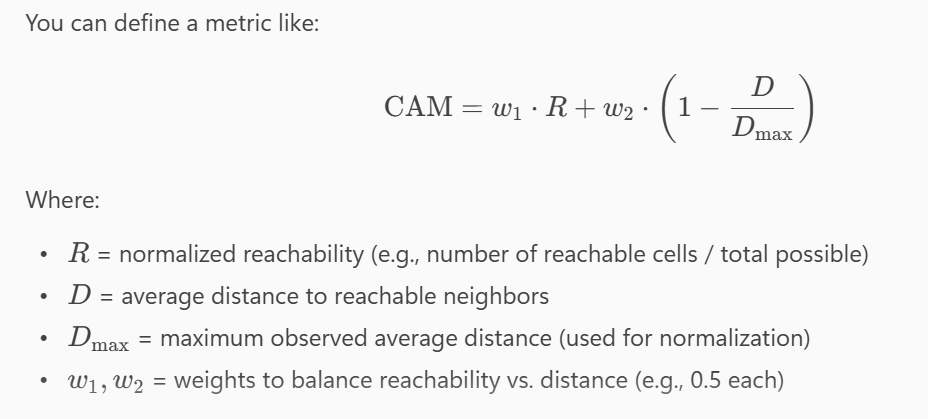

In [ ]:
def compute_composite_accessibility(grid: gpd.GeoDataFrame, reachable_col: str, distance_col: str, weight_reach: float = 0.7, weight_dist: float = 0.3) -> gpd.GeoDataFrame:
    # Normalize reachability
    max_reach = grid[reachable_col].max()
    grid["reach_norm"] = grid[reachable_col] / max_reach if max_reach > 0 else 0

    # Normalize distance (inverted: lower distance = higher accessibility)
    max_dist = grid[distance_col].max()
    grid["dist_norm"] = 1 - (grid[distance_col] / max_dist) if max_dist > 0 else 0

    # Composite Accessibility Metric
    grid["CAM"] = weight_reach * grid["reach_norm"] + weight_dist * grid["dist_norm"]

    return grid



In [ ]:
CAM_grid = compute_composite_accessibility(grid, reachable_col="reachable_cells_hazard", distance_col="avg_distance_hazard")

In [ ]:
def plot_cam_choropleth(grid: gpd.GeoDataFrame, cam_column: str = "CAM"):
    import matplotlib.pyplot as plt

    fig, ax = plt.subplots(1, 1, figsize=(10, 10))
    grid.plot(
        column=cam_column,
        ax=ax,
        legend=True,
        cmap="viridis",
        edgecolor="grey",
        linewidth=0.2
    )
    ax.set_title("Composite Accessibility Metric (CAM)", fontsize=14)
    ax.axis("off")
    plt.tight_layout()
    plt.show()


In [ ]:
plot_cam_choropleth(grid)

## New since 14 July, not implemented in accessibility.py yet

### Define what 'accessible' is

In [ ]:
def accessible_cells(gdf: gpd.GeoDataFrame) -> gpd.GeoDataFrame:
    gdf = gdf.copy()
    if gdf['reachable_cells_hazard'].isnull().all():
        gdf['access_txt'] == 'Not accessible, no reachable neighbours',
        gdf['accessibility'] == 0
    else:
        gdf

        raise ValueError("No accessible cells found in the GeoDataFrame.")

### Develop disconnected islands workflow

In [ ]:

from shapely.ops import transform

# === ISLAND COMPUTATION ===
def compute_island_geodataframe_from_graph(graph_pickle_path: str, hazard_threshold: float) -> gpd.GeoDataFrame:
    with open(graph_pickle_path, "rb") as f:
        G = pickle.load(f)
        G = nx.DiGraph(G)

    G = project_graph_coords(G, from_crs="EPSG:4326", to_crs="EPSG:28992")
    G = filter_hazard_graph(G, hazard_threshold, hazard_column="EV2_ma")

    # Identify strongly connected components
    components = list(nx.strongly_connected_components(G))
    fid_to_island = {}

    # Assign island_id to each fid
    for i, comp in enumerate(components):
        subgraph = G.subgraph(comp)
        for u, v, data in subgraph.edges(data=True):
            fid_to_island[v] = i  # Using 'v' as fid since it's the target node in directed graph

    # Build edge records with geometry and length
    records = []

    for u, v, data in G.edges(data=True):
        length_m = data.get("length", None)
        if length_m is None:
            print(f"Length not found for edge ({u}, {v}), calculating from geometry.")
            geom = LineString([(G.nodes[u]["x"], G.nodes[u]["y"]),
                               (G.nodes[v]["x"], G.nodes[v]["y"])])
            length_m = geom.length  

        island_id = fid_to_island.get(v, -1)

        record = data.copy()
        record["geometry"] = data['geometry'] #projected_geom
        record["length_m"] = length_m
        record["island_id"] = island_id
        records.append(record)

    # Create GeoDataFrame
    gdf = gpd.GeoDataFrame(records, geometry="geometry", crs="EPSG:28992")

    # Compute island sizes using groupby
    island_sizes = gdf.groupby("island_id")["length_m"].sum().reset_index()
    island_sizes["island_size_km"] = island_sizes["length_m"] / 1000.0  # Convert to km
    island_sizes = island_sizes[["island_id", "island_size_km"]]

    # Merge island sizes back into GeoDataFrame
    gdf = gdf.merge(island_sizes, on="island_id", how="left")
    gdf["island_size_km"] = gdf["island_size_km"].fillna(0.0)

    return gdf


In [ ]:
islands = compute_island_geodataframe_from_graph(hazard_graph_path, hazard_threshold=0.2)

In [ ]:
# drop identical rows #TODO: why is each row repeated? what implications does it have and should we fix it from the root cause or si this ok?
islands = islands.drop_duplicates(subset=["geometry", "island_id"])


Ook de resultaten zijn hier nu raar van die islands. hoe kan dat nou ineens na niewue overlay?

In [ ]:
import matplotlib.pyplot as plt

# Convert island_id to string to treat it as categorical
islands['island_id'] = islands['island_id'].astype(str)

# Use a categorical colormap with enough colors
# 'tab20' only has 20 colors, so for 90+ categories, use 'tab20' with interpolation
cmap = plt.cm.get_cmap('tab20', len(islands['island_id'].unique()))

islands = islands.set_crs("EPSG:4326", allow_override=True).to_crs("epsg:28992")  # Ensure CRS is set correctly

# Plot with legend outside the map
islands.explore(
    column='island_id',
    cmap=cmap,
    categorical=True,
    legend=False,
    height=600
)


In [ ]:
# Overlay hazard raster (tif) with the islands vector data
import rasterio
from rasterio.plot import show

fig, ax = plt.subplots(figsize=(10, 10))

# Plot the raster
with rasterio.open(hazard_file) as src:
    raster_crs = src.crs
    raster_data = src.read(1)
    show(raster_data, ax=ax, cmap='Blues', title='Flood Depth Raster',vmin=0.0, vmax=3.0, transform=src.transform)

# Plot the islands on top
islands_plot = islands.to_crs(raster_crs)
islands_plot.plot(ax=ax, column='island_id', cmap=cmap, legend=False, lw=0.5)

bounds = islands_plot.total_bounds

# Turn off legend
ax.set_title('Flood Depth Raster with Islands Overlay')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_xlim(bounds[0], bounds[2])
ax.set_ylim(bounds[1], bounds[3])

plt.show()

In [ ]:
# Verification of removed edges
graph_pickle_path = output_path.joinpath("base_graph.p")
with open(graph_pickle_path, "rb") as f:
    G_orig = pickle.load(f)
    G_orig = nx.DiGraph(G_orig)

G_orig = project_graph_coords(G_orig, from_crs="EPSG:4326", to_crs="EPSG:28992")

# make a list from all the rfids in islands
rfids_in_islands = islands['rfid'].unique().tolist()

# making gdf out of edges with an rfid that is not in the islands
removed_edges_gdf = gpd.GeoDataFrame(
    [(data['osmid'], data['rfid'], data['geometry']) for u, v, data in G_orig.edges(data=True) if not data.get("rfid") in rfids_in_islands],
    columns=['osmid', 'rfid', 'geometry'],
    crs="EPSG:28992"
)
# removed_edges_gdf.explore(lw=2, color="red", tooltip=True, tiles = 'CartoDB positron') # use grey tiles as base layer

# alternative, making a gdf out of the edges after removing the edges with an rfid that is in the islands
G_orig_copy= G_orig.copy()

# remove all the edges that have a rfid in the islands
for u, v, data in list(G_orig_copy.edges(data=True)):
    if data.get("rfid") in rfids_in_islands:
        G_orig_copy.remove_edge(u, v)

removed_edges_gdf_2 = gpd.GeoDataFrame(
    [(data['osmid'], data['rfid'], data['geometry']) for u, v, data in G_orig_copy.edges(data=True)],
    columns=['osmid', 'rfid', 'geometry'],
    crs="EPSG:28992"
)

print(f'Both approaches yield same result: {removed_edges_gdf.equals(removed_edges_gdf_2)}')

removed_edges_gdf_2.explore(lw=2, color="red", tooltip=True, tiles = 'CartoDB positron') # use grey tiles as base layer
